# IMAGE COLORIZATION — U-NET (LAB COLOR SPACE)

Image colorization is the task of automatically reconstructing plausible color information from a grayscale image using deep learning methods.

This problem is inherently ambiguous because a single grayscale image may correspond to many valid color versions.
For example:

- a car can be red, blue, black, or white,
- clothing can have arbitrary colors,
- lighting conditions may change the perceived appearance of objects.

As a result, the model must learn not only low-level textures and edges, but also higher-level semantic relationships between objects and their typical colors.

In this notebook, we build a baseline deep learning solution for automatic image colorization



## Goal
Train a neural network that converts **grayscale images** into **color images**.

## Task
- **Input:** L channel — the lightness (grayscale-like) component of a LAB image
- **Output:** A and B channels — the color components

## Why LAB instead of RGB?
In the LAB color space, luminance (L) and chrominance (A, B) are **separated**.
This means the model only needs to learn colorization, not brightness.
In RGB, all three channels encode both color and brightness together,
making the task harder and outputs blurrier.

## 0. Imports

In [1]:
import os
import math
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from skimage.color import rgb2lab, lab2rgb
from skimage.metrics import structural_similarity as ssim

# Fix for OpenMP conflict on Windows
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

# ---------- Device Detection ----------
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("NVIDIA GPU detected — using CUDA.")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Apple Silicon detected — using MPS.")
else:
    try:
        import torch_directml
        if torch_directml.is_available():
            device = torch_directml.device()
            print("AMD/Windows GPU detected — using DirectML.")
        else:
            raise ImportError
    except ImportError:
        device = torch.device("cpu")
        print("No GPU found — falling back to CPU (will be slow).")

NVIDIA GPU detected — using CUDA.


## 1. Dataset

`ColorizationDatasetLAB` loads RGB images, converts them to LAB color space,
and returns:
- **L channel** (input): normalized to [-1, 1] from the original [0, 100] range
- **AB channels** (target): normalized to [-1, 1] from the original [-128, 128] range

Normalization to [-1, 1] is important because the model's output uses `tanh`,
which also produces values in that range.

In [2]:
class ColorizationDatasetLAB(Dataset):
    def __init__(self, root_dir, size=128, limit=None):
        """
        Args:
            root_dir: Path to folder containing images.
            size:     Images are resized to (size x size).
            limit:    Optional cap on number of images loaded.
        """
        exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
        paths = [
            f for f in os.listdir(root_dir)
            if os.path.splitext(f)[1].lower() in exts
        ]
        if limit:
            paths = paths[:limit]

        self.paths = [os.path.join(root_dir, p) for p in paths]
        self.size = size
        self.tf = transforms.Compose([
            transforms.Resize((size, size))
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        img = self.tf(img)
        img_np = np.array(img).astype(np.float32) / 255.0  # [0, 1]

        # Convert to LAB
        lab = rgb2lab(img_np).astype(np.float32)

        # L: [0, 100] → [-1, 1]
        L = lab[:, :, 0] / 50.0 - 1.0

        # AB: [-128, 128] → [-1, 1]
        AB = lab[:, :, 1:] / 128.0

        L  = torch.from_numpy(L).unsqueeze(0)          # (1, H, W)
        AB = torch.from_numpy(AB).permute(2, 0, 1)     # (2, H, W)

        return L, AB

## 2. DataLoader and Data Split

We split the dataset into:
- **80%** training
- **10%** validation (used to monitor overfitting during training)
- **10%** test (used only for final evaluation — never seen during training)

A fixed random seed ensures reproducible splits.

In [3]:
ROOT_DIR = "data/images"
IMG_SIZE = 128
LIMIT    = 8000
BATCH    = 32

full_dataset = ColorizationDatasetLAB(ROOT_DIR, IMG_SIZE, LIMIT)

train_size = int(0.8 * len(full_dataset))
val_size   = int(0.1 * len(full_dataset))
test_size  = len(full_dataset) - train_size - val_size

train_ds, val_ds, test_ds = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=0)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Train: 6400 | Val: 800 | Test: 800


## 3. Sanity Check — Visualize One Sample

Before training, let's verify that the dataset correctly:
1. Loads an image
2. Converts it to LAB
3. Can reconstruct the original color image from L + AB

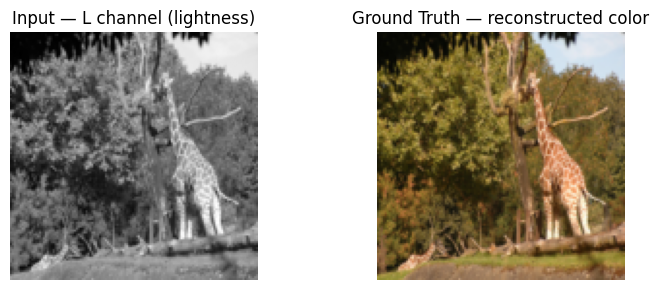

In [4]:
L_sample, AB_sample = full_dataset[0]

L_np  = L_sample.squeeze().numpy()
AB_np = AB_sample.permute(1, 2, 0).numpy()

# Reconstruct LAB → RGB for display
lab_check = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)
lab_check[:, :, 0]  = (L_np + 1.0) * 50.0    # [-1,1] → [0,100]
lab_check[:, :, 1:] = AB_np * 128.0           # [-1,1] → [-128,128]
rgb_check = lab2rgb(lab_check)

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].imshow(L_np, cmap="gray")
axes[0].set_title("Input — L channel (lightness)")
axes[1].imshow(rgb_check)
axes[1].set_title("Ground Truth — reconstructed color")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Model — U-Net

We use a **U-Net** architecture: an encoder-decoder network with **skip connections**.

### Why U-Net?
- The encoder progressively compresses the spatial information (capturing "what")
- The decoder reconstructs the image at full resolution (answering "where")
- Skip connections pass fine spatial detail directly from encoder to decoder,
  preventing loss of edge and texture information

### Architecture Summary
```
Input (1, 128, 128)
    ↓ enc1 → (64, 128, 128)   ──────────────────────┐
    ↓ pool + enc2 → (128, 64, 64)  ───────────┐      │
    ↓ pool + mid  → (256, 32, 32)             │      │
    ↓ up2 + cat + dec2 → (128, 64, 64) ←──────┘      │
    ↓ up1 + cat + dec1 → (64, 128, 128) ←────────────┘
    ↓ out → (2, 128, 128)  [AB channels, tanh output]
```

In [13]:
def conv_block(in_c: int, out_c: int) -> nn.Sequential:
    """Two 3×3 Conv layers with ReLU, same spatial size (padding=1)."""
    return nn.Sequential(
        nn.Conv2d(in_c,  out_c, kernel_size=3, padding=1), nn.ReLU(inplace=True),
        nn.Conv2d(out_c, out_c, kernel_size=3, padding=1), nn.ReLU(inplace=True),
    )


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        #  Encoder 
        self.enc1 = conv_block(1,   64)   # (1,128,128) → (64,128,128)
        self.enc2 = conv_block(64, 128)   # (64,64,64)  → (128,64,64)
        self.pool = nn.MaxPool2d(2)

        #  Bottleneck-
        self.mid  = conv_block(128, 256)  # (128,32,32) → (256,32,32)

        #  Decoder 
        self.up2  = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = conv_block(256, 128)  # 128 (up) + 128 (skip) = 256 in

        self.up1  = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = conv_block(128, 64)   # 64 (up) + 64 (skip) = 128 in

        #  Output: 2 channels (A and B) 
        self.out  = nn.Conv2d(64, 2, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)                               # skip 1
        e2 = self.enc2(self.pool(e1))                   # skip 2
        m  = self.mid(self.pool(e2))                    # bottleneck

        d2 = self.dec2(torch.cat([self.up2(m),  e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return torch.tanh(self.out(d1))   # output in [-1, 1]


model = UNet().to(device)

# Count parameters
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"U-Net parameters: {n_params:,}")

U-Net parameters: 1,861,762


## 5. Loss Function and Optimizer

**L1 Loss** (Mean Absolute Error) is preferred over MSE for image generation because:
- MSE penalizes large errors quadratically, encouraging the model to predict
  the "average" color — leading to desaturated, blurry outputs
- L1 is more robust to outliers and produces sharper, more saturated predictions

**Adam** is used as the optimizer with a learning rate of 1e-3.

In [6]:
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

## 6. Training Loop

Each epoch:
1. Forward pass: predict AB from L
2. Compute L1 loss against ground truth AB
3. Backpropagate and update weights
4. Track average training loss

After each epoch we also compute **validation loss** to detect overfitting.

In [7]:
EPOCHS = 10
train_history = []
val_history   = []

for epoch in range(EPOCHS):
    # --- Training ---
    model.train()
    train_loss = 0.0

    for L_batch, ab_batch in train_loader:
        L_batch  = L_batch.to(device)
        ab_batch = ab_batch.to(device)

        pred = model(L_batch)
        loss = criterion(pred, ab_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train = train_loss / len(train_loader)
    train_history.append(avg_train)

    # --- Validation ---
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for L_batch, ab_batch in val_loader:
            L_batch  = L_batch.to(device)
            ab_batch = ab_batch.to(device)
            pred     = model(L_batch)
            val_loss += criterion(pred, ab_batch).item()

    avg_val = val_loss / len(val_loader)
    val_history.append(avg_val)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f}")

Epoch 01/10 | Train Loss: 0.0723 | Val Loss: 0.0736
Epoch 02/10 | Train Loss: 0.0714 | Val Loss: 0.0735
Epoch 03/10 | Train Loss: 0.0712 | Val Loss: 0.0734
Epoch 04/10 | Train Loss: 0.0711 | Val Loss: 0.0732
Epoch 05/10 | Train Loss: 0.0709 | Val Loss: 0.0731
Epoch 06/10 | Train Loss: 0.0708 | Val Loss: 0.0729
Epoch 07/10 | Train Loss: 0.0707 | Val Loss: 0.0728
Epoch 08/10 | Train Loss: 0.0706 | Val Loss: 0.0726
Epoch 09/10 | Train Loss: 0.0705 | Val Loss: 0.0734
Epoch 10/10 | Train Loss: 0.0704 | Val Loss: 0.0724


## 7. Save the Model

In [8]:
torch.save(model.state_dict(), "unet_lab.pth")
print("Model saved to unet_lab.pth")

# To reload later:
#   model = UNet().to(device)
#   model.load_state_dict(torch.load("unet_lab.pth", map_location=device))
#   model.eval()

Model saved to unet_lab.pth


## 8. Training Curves

Plotting both train and validation loss helps us detect:
- **Underfitting**: both losses are high
- **Overfitting**: training loss keeps falling but validation loss plateaus or rises

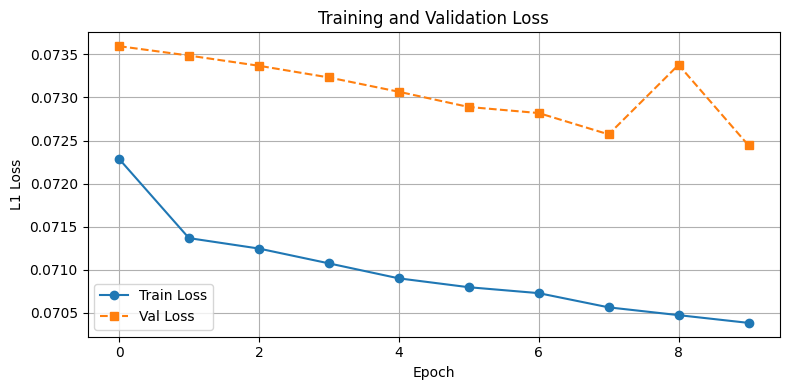

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(train_history, marker="o", label="Train Loss")
plt.plot(val_history,   marker="s", label="Val Loss", linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("L1 Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 9. Quantitative Evaluation — PSNR and SSIM

Visual inspection alone is not enough. We use two standard image quality metrics:

### PSNR (Peak Signal-to-Noise Ratio)
- Measures the ratio between maximum possible pixel value and reconstruction error
- Formula: `PSNR = 10 * log10(MAX² / MSE)`
- Higher is better. Typical values for colorization: 20–30 dB
- Limitation: does not perfectly correlate with perceptual quality

### SSIM (Structural Similarity Index)
- Measures similarity in luminance, contrast, and structure
- Range: [-1, 1], where 1 means identical images
- More closely aligned with human perception than PSNR

We compute both metrics on the **test set** (never seen during training).

In [10]:
def lab_to_rgb_numpy(L_np: np.ndarray, ab_np: np.ndarray) -> np.ndarray:
    """
    Convert L (H, W) and AB (H, W, 2) in normalized [-1,1] range to
    an RGB image as float32 [0,1].
    """
    lab = np.zeros((L_np.shape[0], L_np.shape[1], 3), dtype=np.float32)
    lab[:, :, 0]  = (L_np + 1.0) * 50.0
    lab[:, :, 1:] = np.clip(ab_np, -1, 1) * 128.0
    return lab2rgb(lab).astype(np.float32)


def compute_psnr(img_true: np.ndarray, img_pred: np.ndarray) -> float:
    """PSNR between two RGB images in [0,1]."""
    mse = np.mean((img_true - img_pred) ** 2)
    if mse == 0:
        return float("inf")
    return 10.0 * math.log10(1.0 / mse)


def compute_ssim(img_true: np.ndarray, img_pred: np.ndarray) -> float:
    """
    Mean SSIM across RGB channels.
    Expects images of shape (H, W, 3) in [0,1].
    """
    scores = []
    for c in range(3):
        score = ssim(img_true[:, :, c], img_pred[:, :, c],
                     data_range=1.0)
        scores.append(score)
    return float(np.mean(scores))


#  Evaluate on test set 
model.eval()
psnr_scores, ssim_scores = [], []

with torch.no_grad():
    for L_batch, ab_batch in test_loader:
        pred_batch = model(L_batch.to(device)).cpu()

        for i in range(L_batch.size(0)):
            L_np   = L_batch[i].squeeze().numpy()
            ab_np  = ab_batch[i].permute(1, 2, 0).numpy()
            pr_np  = pred_batch[i].permute(1, 2, 0).numpy()

            img_true = lab_to_rgb_numpy(L_np, ab_np)
            img_pred = lab_to_rgb_numpy(L_np, pr_np)

            psnr_scores.append(compute_psnr(img_true, img_pred))
            ssim_scores.append(compute_ssim(img_true, img_pred))

mean_psnr = np.mean(psnr_scores)
mean_ssim = np.mean(ssim_scores)

print(f"\n=== Test Set Metrics ===")
print(f"PSNR (mean): {mean_psnr:.2f} dB")
print(f"SSIM (mean): {mean_ssim:.4f}")


=== Test Set Metrics ===
PSNR (mean): 23.54 dB
SSIM (mean): 0.9158


## 10. Visualize Predictions

For each sample we show:
1. **Input** — the L channel (grayscale lightness)
2. **Prediction** — AB channels predicted by the model, combined with input L
3. **Ground Truth** — original color image

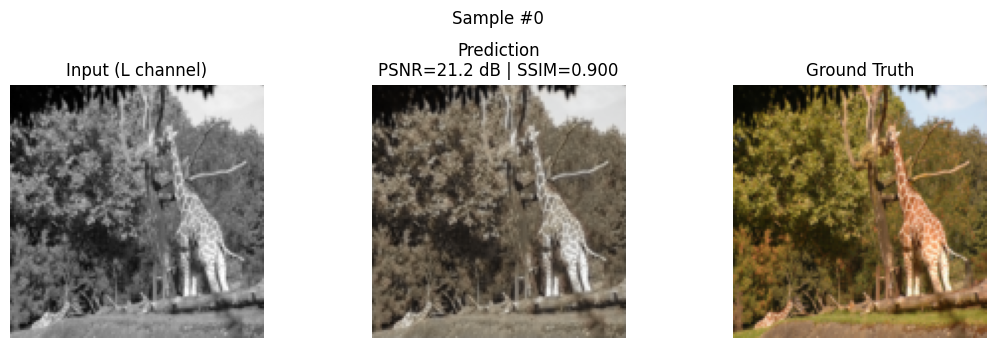

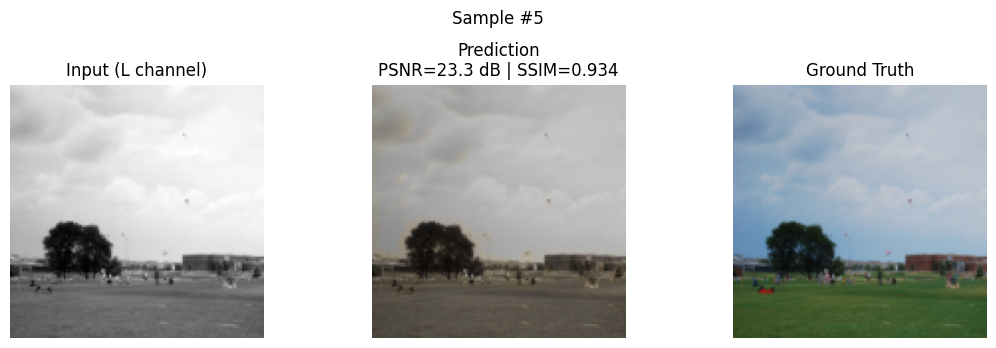

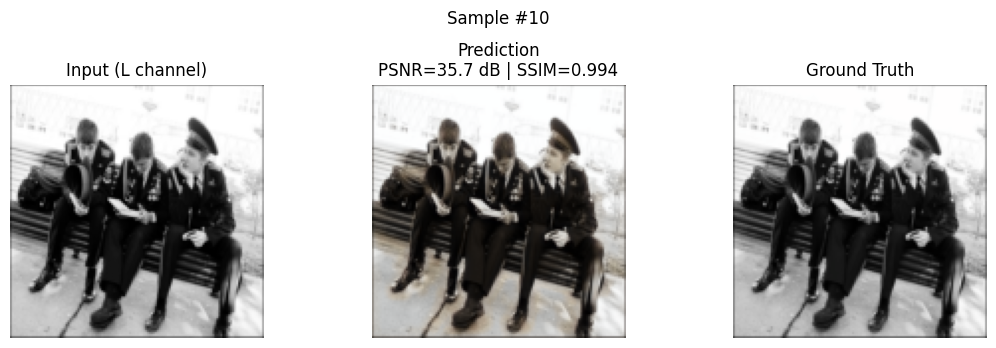

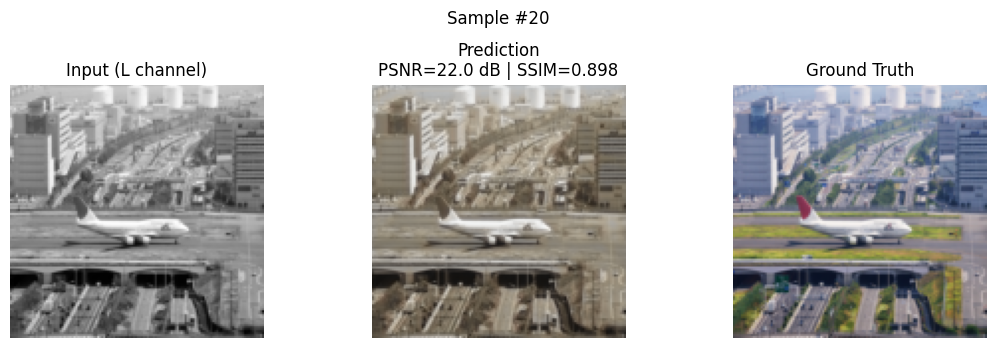

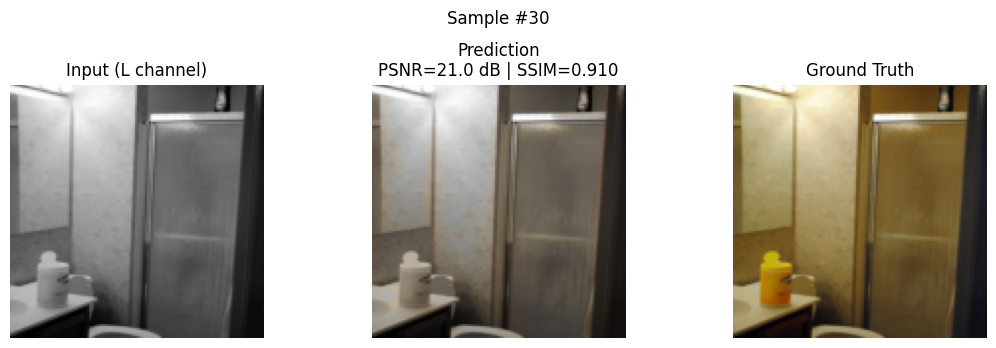

In [11]:
def visualize(idx: int, dataset: Dataset, title: str = "") -> None:
    model.eval()
    L, ab = dataset[idx]

    with torch.no_grad():
        pred_ab = model(L.unsqueeze(0).to(device)).cpu().squeeze(0)

    L_np   = L.squeeze().numpy()
    ab_np  = ab.permute(1, 2, 0).numpy()
    pr_np  = pred_ab.permute(1, 2, 0).numpy()

    img_pred = lab_to_rgb_numpy(L_np, pr_np)
    img_true = lab_to_rgb_numpy(L_np, ab_np)

    psnr_val = compute_psnr(img_true, img_pred)
    ssim_val = compute_ssim(img_true, img_pred)

    fig, ax = plt.subplots(1, 3, figsize=(11, 3.5))
    if title:
        fig.suptitle(title, fontsize=12)

    ax[0].imshow(L_np, cmap="gray")
    ax[0].set_title("Input (L channel)")

    ax[1].imshow(img_pred)
    ax[1].set_title(f"Prediction\nPSNR={psnr_val:.1f} dB | SSIM={ssim_val:.3f}")

    ax[2].imshow(img_true)
    ax[2].set_title("Ground Truth")

    for a in ax:
        a.axis("off")

    plt.tight_layout()
    plt.show()


for idx in [0, 5, 10, 20, 30]:
    visualize(idx, full_dataset, title=f"Sample #{idx}")

## 11. Metric Distribution — PSNR and SSIM Histograms

Looking at per-image distributions helps us understand variance:
are most predictions good, or is the average dragged up by a few easy images?

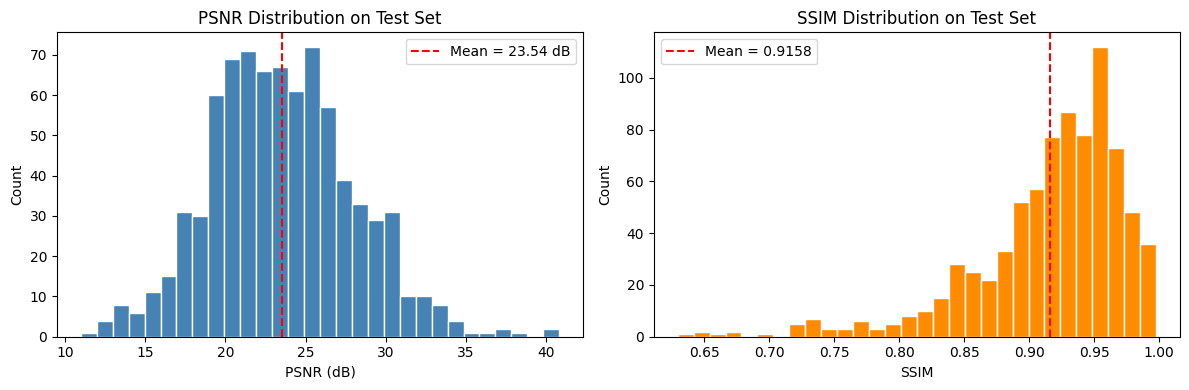

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(psnr_scores, bins=30, color="steelblue", edgecolor="white")
axes[0].axvline(mean_psnr, color="red", linestyle="--", label=f"Mean = {mean_psnr:.2f} dB")
axes[0].set_xlabel("PSNR (dB)")
axes[0].set_ylabel("Count")
axes[0].set_title("PSNR Distribution on Test Set")
axes[0].legend()

axes[1].hist(ssim_scores, bins=30, color="darkorange", edgecolor="white")
axes[1].axvline(mean_ssim, color="red", linestyle="--", label=f"Mean = {mean_ssim:.4f}")
axes[1].set_xlabel("SSIM")
axes[1].set_ylabel("Count")
axes[1].set_title("SSIM Distribution on Test Set")
axes[1].legend()

plt.tight_layout()
plt.show()

## 12. Summary and Future Improvements

### What works well
- LAB color space separates lightness from color → simpler learning task
- U-Net skip connections preserve spatial detail
- L1 loss avoids the "gray blurriness" problem of MSE

### Metrics 


- Peak Signal-to-Noise Ratio evaluates reconstruction quality in decibels
In colorization:
PSNR is useful for measuring low-level similarity , but it does not fully capture perceptual realism
- Structural Similarity Index measures perceptual similarity between images.

The baseline U-Net achieved:

- PSNR = 23.54 dB
- SSIM = 0.9158

These results indicate that the model successfully reconstructs the overall image structure and produces visually consistent colorizations.

PSNR Analysis

PSNR measures pixel-level reconstruction quality.
A value of 23.54 dB is considered good for image colorization tasks, especially for a relatively small dataset of 8,000 images.

This means that:

- the predicted colors are generally close to the ground-truth colors,
- large reconstruction errors are relatively rare,
- object boundaries and global color regions are reconstructed correctly.

The relatively high PSNR is mainly due to the use of the L1 loss, which encourages accurate pixel-wise predictions.

However, PSNR alone does not guarantee visually realistic colors.
A model can achieve a good PSNR while still producing slightly desaturated or overly smooth outputs.

SSIM Analysis

The SSIM value of 0.9158 indicates strong preservation of:

-image structure,
- edges,
- textures,
- spatial consistency.

Since SSIM is close to 1, the generated images remain structurally very similar to the original ground-truth images.

This confirms that the U-Net architecture and its skip connections successfully preserve fine spatial details during reconstruction



### Current limitations
Even with these improvements, a basic U-Net + L1 loss still has limits:
- Outputs can be desaturated or show incorrect hues
- Fine-grained color boundaries may be blurry
- The model cannot "reason" about object semantics (sky → blue, grass → green)

### What we will do next

We'll leverage the existing U-net architecture and improve the quality using a GAN model, which consists of a generator and a discriminator. The discriminator forces the generator to produce *realistic* color distributions. We'll also use a patchgun to evaluate local areas, avoiding the need to evaluate the entire image. The goal is to achieve better colorization results. Afterwards, we'll compare the models.